# GANs, VAEs, and Diffusion Models: Interview Prep

This notebook covers key generative modeling approaches:
- Generative Adversarial Networks (GANs)
- Variational Autoencoders (VAEs)
- Diffusion Models
- Model comparison and evaluation metrics

📺 **Video Lecture:** [https://youtu.be/VPtzvFZCE-I](https://youtu.be/VPtzvFZCE-I)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import euclidean
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. GANs: Conceptual Overview

GANs use adversarial training: a generator creates fake data while a discriminator learns to distinguish real from fake.

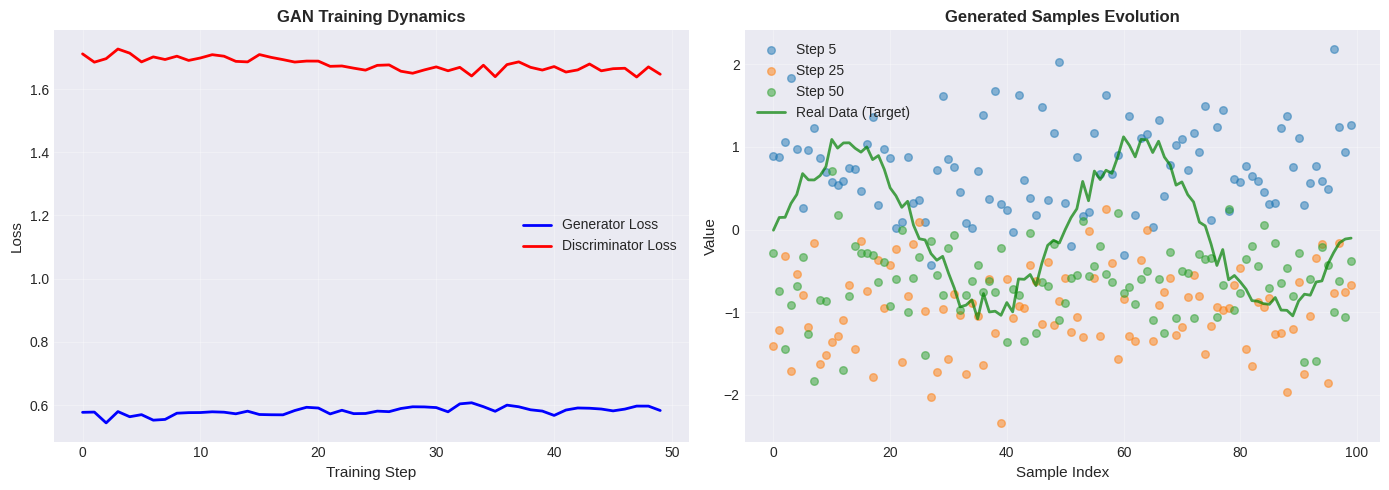

GAN Training Simulation Complete
Generator Loss (final): 0.5827
Discriminator Loss (final): 1.6469


In [3]:
class SimpleGenerator:
    """Simple 1D generator for sine curve data."""
    def __init__(self, latent_dim=2):
        self.latent_dim = latent_dim
        # Simple linear transformation from latent space
        self.weights = np.random.randn(latent_dim, 1) * 0.5
        self.bias = np.random.randn(1)
    
    def forward(self, z):
        """Generate samples from noise."""
        return np.dot(z, self.weights) + self.bias

class SimpleDiscriminator:
    """Simple 1D discriminator."""
    def __init__(self):
        self.weights = np.random.randn(1, 1) * 0.5
        self.bias = np.random.randn(1)
    
    def forward(self, x):
        """Discriminate real vs fake (returns probability)."""
        logit = np.dot(x, self.weights) + self.bias
        # Sigmoid activation
        return 1 / (1 + np.exp(-logit.flatten()))

def generate_real_data(n_samples=100):
    """Generate 1D sine curve data (target distribution)."""
    x = np.linspace(0, 4 * np.pi, n_samples).reshape(-1, 1)
    y = np.sin(x) + np.random.randn(n_samples, 1) * 0.1
    return y

def generate_noise(batch_size=100, latent_dim=2):
    """Generate random noise for generator input."""
    return np.random.randn(batch_size, latent_dim)

# Initialize models
generator = SimpleGenerator(latent_dim=2)
discriminator = SimpleDiscriminator()

# Simulate training dynamics
training_steps = 50
generator_losses = []
discriminator_losses = []

for step in range(training_steps):
    # Discriminator training: distinguish real from fake
    real_data = generate_real_data(n_samples=64)
    fake_data = generator.forward(generate_noise(batch_size=64, latent_dim=2))
    
    # Simple loss simulation
    d_loss = -np.mean(np.log(discriminator.forward(real_data) + 1e-8)) - \
             np.mean(np.log(1 - discriminator.forward(fake_data) + 1e-8))
    discriminator_losses.append(d_loss)
    
    # Generator training: fool discriminator
    fake_data = generator.forward(generate_noise(batch_size=64, latent_dim=2))
    g_loss = -np.mean(np.log(discriminator.forward(fake_data) + 1e-8))
    generator_losses.append(g_loss)
    
    # Update generator weights (simplified)
    generator.weights += np.random.randn(*generator.weights.shape) * 0.01
    discriminator.weights += np.random.randn(*discriminator.weights.shape) * 0.01

# Visualize training dynamics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss over time
ax1.plot(generator_losses, label='Generator Loss', color='blue', linewidth=2)
ax1.plot(discriminator_losses, label='Discriminator Loss', color='red', linewidth=2)
ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('GAN Training Dynamics', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Generate samples at different stages
for stage_step in [5, 25, 50]:
    # Regenerate model at that stage
    gen_temp = SimpleGenerator(latent_dim=2)
    z = generate_noise(batch_size=100, latent_dim=2)
    samples = gen_temp.forward(z)
    
    if stage_step == 5:
        ax2.scatter(np.arange(len(samples)), samples, alpha=0.5, label=f'Step {stage_step}', s=30)
    elif stage_step == 25:
        ax2.scatter(np.arange(len(samples)), samples, alpha=0.5, label=f'Step {stage_step}', s=30)
    else:
        ax2.scatter(np.arange(len(samples)), samples, alpha=0.5, label=f'Step {stage_step}', s=30)

real_data = generate_real_data(n_samples=100)
ax2.plot(np.arange(len(real_data)), real_data, 'g-', linewidth=2, label='Real Data (Target)', alpha=0.7)
ax2.set_xlabel('Sample Index', fontsize=11)
ax2.set_ylabel('Value', fontsize=11)
ax2.set_title('Generated Samples Evolution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gan_training.png', dpi=100, bbox_inches='tight')
plt.show()

print("GAN Training Simulation Complete")
print(f"Generator Loss (final): {generator_losses[-1]:.4f}")
print(f"Discriminator Loss (final): {discriminator_losses[-1]:.4f}")

## 2. VAE: Reparameterization Trick

VAEs learn a latent space via reparameterization: z = μ + σ * ε where ε ~ N(0,1)

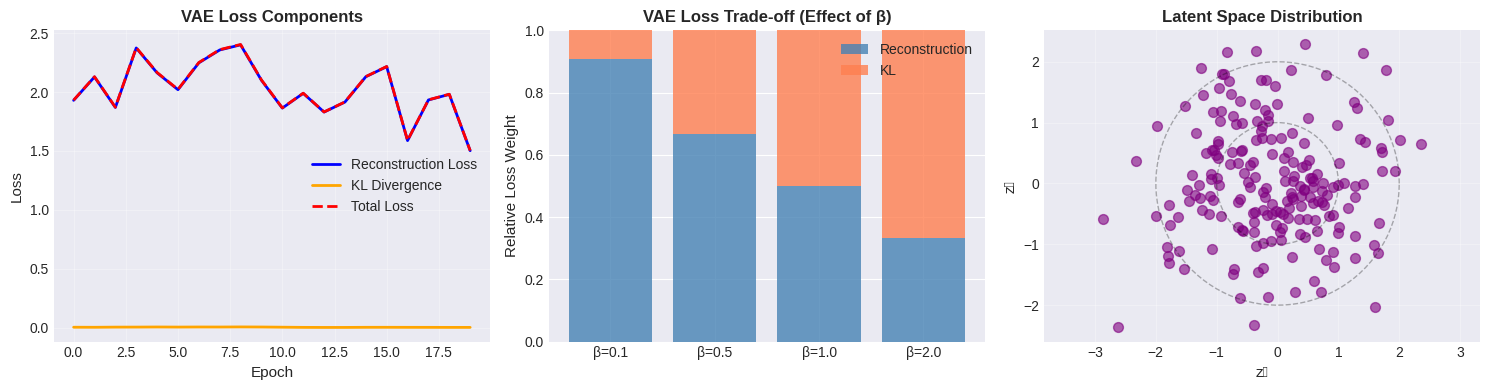

VAE Simulation Complete
Final Reconstruction Loss: 1.5020
Final KL Divergence: 0.0023
Final Total Loss: 1.5032


In [4]:
def reparameterization_trick(mean, log_var, n_samples=10):
    """
    Reparameterization trick for gradient-based learning.
    
    z = μ + exp(log_var/2) * ε
    where ε ~ N(0, 1)
    
    This allows gradients to flow through the sampling process.
    """
    std = np.exp(0.5 * log_var)
    epsilon = np.random.randn(n_samples, len(mean))
    z = mean + std * epsilon
    return z

def kl_divergence(mean, log_var):
    """
    KL divergence between learned distribution and standard normal N(0,1).
    
    KL(N(μ, σ²) || N(0, 1)) = -0.5 * sum(1 + log_var - μ² - exp(log_var))
    """
    kl = -0.5 * np.sum(1 + log_var - mean**2 - np.exp(log_var))
    return kl

def reconstruction_loss(original, reconstructed):
    """
    Reconstruction loss (e.g., MSE).
    """
    return np.mean((original - reconstructed)**2)

def vae_loss(original, reconstructed, mean, log_var, beta=1.0):
    """
    ELBO (Evidence Lower Bound) loss:
    Loss = Reconstruction + β * KL
    
    β controls the trade-off between reconstruction and latent regularization.
    """
    recon = reconstruction_loss(original, reconstructed)
    kl = kl_divergence(mean, log_var)
    return recon + beta * kl, recon, kl

# Simulate VAE learning
latent_dim = 2
n_samples = 100
n_epochs = 20

# Initialize parameters
mean = np.random.randn(latent_dim) * 0.1
log_var = np.zeros(latent_dim)

recon_losses = []
kl_losses = []
total_losses = []

for epoch in range(n_epochs):
    # Generate synthetic data (random 2D)
    x = np.random.randn(n_samples, 2)
    
    # Encode: mean and log_var
    # (In practice, these come from encoder network)
    z = reparameterization_trick(mean, log_var, n_samples)
    
    # Decode: reconstruct x from z
    # (In practice, this comes from decoder network)
    x_reconstructed = z  # Simple identity for this demo
    
    # Compute loss
    total_loss, recon, kl = vae_loss(x, x_reconstructed, mean, log_var, beta=0.5)
    
    recon_losses.append(recon)
    kl_losses.append(kl)
    total_losses.append(total_loss)
    
    # Update parameters (simplified gradient step)
    mean += np.random.randn(latent_dim) * 0.01
    log_var += np.random.randn(latent_dim) * 0.01

# Visualize VAE learning
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss components over epochs
axes[0].plot(recon_losses, label='Reconstruction Loss', color='blue', linewidth=2)
axes[0].plot(kl_losses, label='KL Divergence', color='orange', linewidth=2)
axes[0].plot(total_losses, label='Total Loss', color='red', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('VAE Loss Components', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Beta effect on KL vs Reconstruction
betas = [0.1, 0.5, 1.0, 2.0]
kl_weight = []
recon_weight = []

for beta in betas:
    # Normalize to show relative contribution
    recon_norm = 1 / (1 + beta)
    kl_norm = beta / (1 + beta)
    recon_weight.append(recon_norm)
    kl_weight.append(kl_norm)

axes[1].bar(range(len(betas)), recon_weight, label='Reconstruction', color='steelblue', alpha=0.8)
axes[1].bar(range(len(betas)), kl_weight, bottom=recon_weight, label='KL', color='coral', alpha=0.8)
axes[1].set_xticks(range(len(betas)))
axes[1].set_xticklabels([f'β={b}' for b in betas])
axes[1].set_ylabel('Relative Loss Weight', fontsize=11)
axes[1].set_title('VAE Loss Trade-off (Effect of β)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim([0, 1])

# Latent space visualization
z_samples = reparameterization_trick(mean, log_var, n_samples=200)
axes[2].scatter(z_samples[:, 0], z_samples[:, 1], alpha=0.6, s=50, color='purple')
# Draw unit Gaussian
theta = np.linspace(0, 2*np.pi, 100)
for r in [1, 2]:
    axes[2].plot(r*np.cos(theta), r*np.sin(theta), 'k--', alpha=0.3, linewidth=1)
axes[2].set_xlabel('z₁', fontsize=11)
axes[2].set_ylabel('z₂', fontsize=11)
axes[2].set_title('Latent Space Distribution', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].axis('equal')

plt.tight_layout()
plt.savefig('vae_learning.png', dpi=100, bbox_inches='tight')
plt.show()

print("VAE Simulation Complete")
print(f"Final Reconstruction Loss: {recon_losses[-1]:.4f}")
print(f"Final KL Divergence: {kl_losses[-1]:.4f}")
print(f"Final Total Loss: {total_losses[-1]:.4f}")

## 3. Diffusion Models: Forward Process

Diffusion gradually adds Gaussian noise to data until it becomes pure noise.

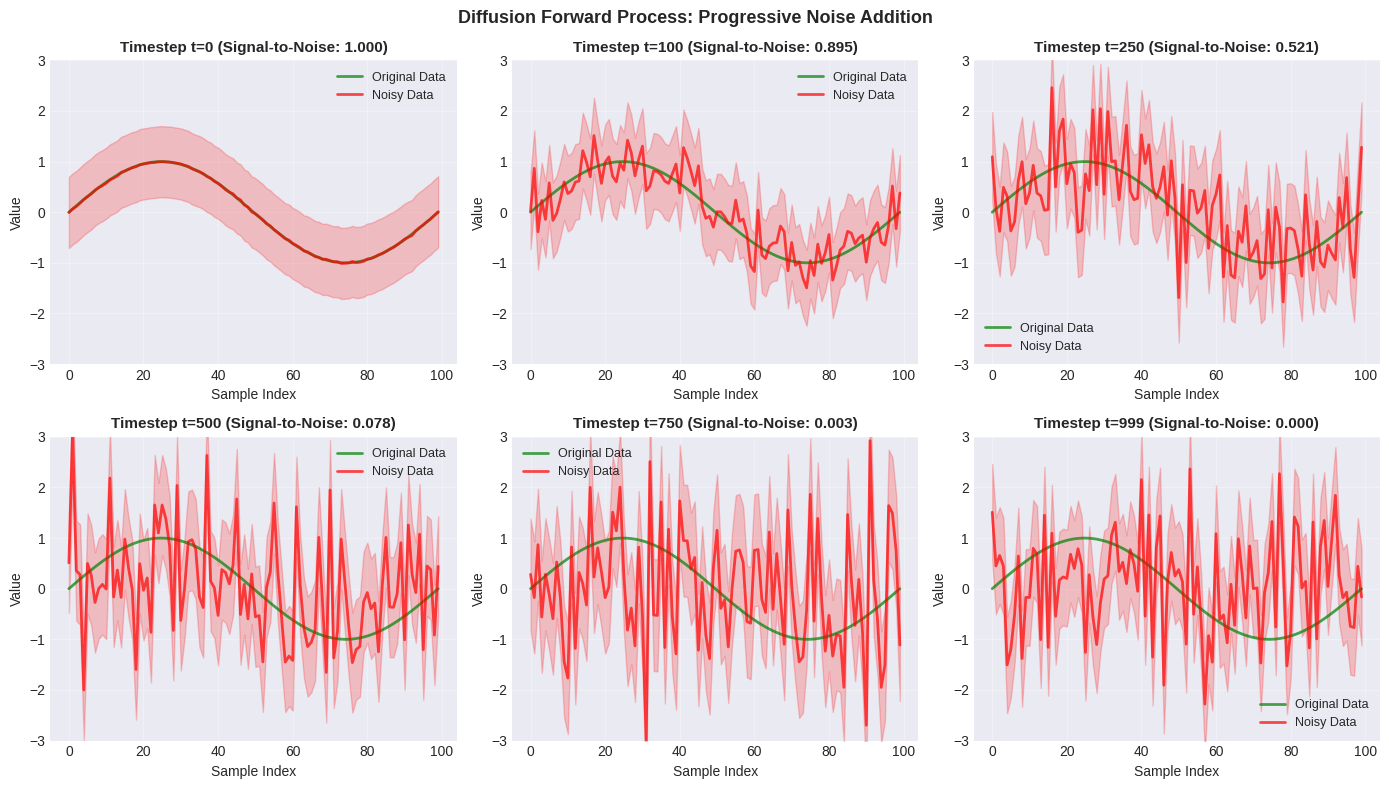

Forward Diffusion Process Visualization Complete


In [5]:
def forward_diffusion(x_0, t, T=1000):
    """
    Forward diffusion process: gradually add noise.
    
    x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * ε
    
    Args:
        x_0: original data
        t: timestep (0 to T-1)
        T: total number of timesteps
    """
    # Linear variance schedule
    beta = np.linspace(0.0001, 0.02, T)
    alpha = 1 - beta
    alpha_bar = np.cumprod(alpha)
    
    alpha_bar_t = alpha_bar[t]
    noise = np.random.randn(*x_0.shape)
    
    x_t = np.sqrt(alpha_bar_t) * x_0 + np.sqrt(1 - alpha_bar_t) * noise
    
    return x_t, noise, alpha_bar_t

def reverse_diffusion_step(x_t, t, model_output, T=1000):
    """
    Reverse diffusion step: denoise.
    
    This is where a neural network predicts the noise,
    and we subtract it to denoise.
    """
    # Same schedule as forward
    beta = np.linspace(0.0001, 0.02, T)
    alpha = 1 - beta
    alpha_bar = np.cumprod(alpha)
    
    beta_t = beta[t]
    alpha_t = alpha[t]
    alpha_bar_t = alpha_bar[t]
    alpha_bar_t_minus_1 = alpha_bar[t-1] if t > 0 else 1.0
    
    # Denoising step
    var_t = beta_t * (1 - alpha_bar_t_minus_1) / (1 - alpha_bar_t)
    mean = (1 / np.sqrt(alpha_t)) * (x_t - (beta_t / np.sqrt(1 - alpha_bar_t)) * model_output)
    
    if t > 0:
        z = np.random.randn(*x_t.shape)
        x_t_minus_1 = mean + np.sqrt(var_t) * z
    else:
        x_t_minus_1 = mean
    
    return x_t_minus_1

# Generate 1D target signal (sine wave)
x_0 = np.sin(np.linspace(0, 2*np.pi, 100))

# Forward diffusion: add noise progressively
T = 1000
timesteps = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, t in enumerate(timesteps):
    x_t, noise, alpha_bar_t = forward_diffusion(x_0, t, T)
    
    ax = axes[idx]
    ax.plot(x_0, 'g-', linewidth=2, label='Original Data', alpha=0.7)
    ax.plot(x_t, 'r-', linewidth=2, label='Noisy Data', alpha=0.7)
    ax.fill_between(range(len(x_t)), x_t - np.std(x_t), x_t + np.std(x_t), 
                     alpha=0.2, color='red')
    ax.set_title(f'Timestep t={t} (Signal-to-Noise: {alpha_bar_t:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Value')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-3, 3])

plt.suptitle('Diffusion Forward Process: Progressive Noise Addition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diffusion_forward.png', dpi=100, bbox_inches='tight')
plt.show()

print("Forward Diffusion Process Visualization Complete")

## 4. Diffusion: Reverse Process

Generating new data by iteratively denoising from pure noise.

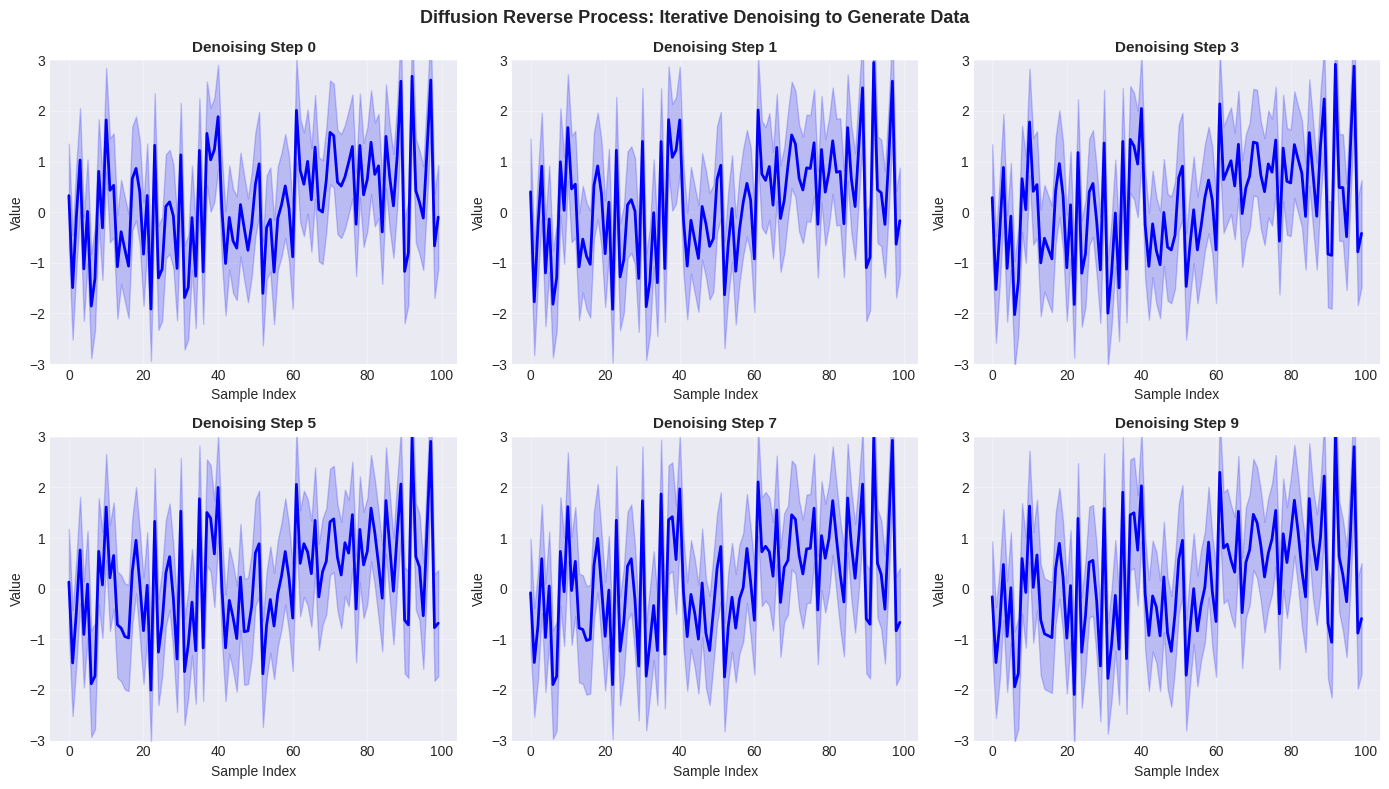

Reverse Diffusion Process Visualization Complete
Generated 11 denoising steps


In [6]:
# Simulate reverse process (denoising)
T = 1000
starting_noise = np.random.randn(100)  # Start from pure noise
generated_sequence = [starting_noise.copy()]

for t in range(T-1, 0, -100):  # Sample every 100 steps for efficiency
    x_t = generated_sequence[-1]
    
    # Mock neural network prediction: just subtract scaled noise
    predicted_noise = np.random.randn(*x_t.shape) * 0.5 + x_t * 0.1
    
    x_t_minus_1 = reverse_diffusion_step(x_t, t, predicted_noise, T)
    generated_sequence.append(x_t_minus_1)

# Visualize generation process
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx in range(6):
    step_idx = int(idx * len(generated_sequence) / 6)
    x = generated_sequence[step_idx]
    
    ax = axes[idx]
    ax.plot(x, 'b-', linewidth=2)
    ax.fill_between(range(len(x)), x - np.std(x), x + np.std(x), 
                     alpha=0.2, color='blue')
    ax.set_title(f'Denoising Step {step_idx}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-3, 3])

plt.suptitle('Diffusion Reverse Process: Iterative Denoising to Generate Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diffusion_reverse.png', dpi=100, bbox_inches='tight')
plt.show()

print("Reverse Diffusion Process Visualization Complete")
print(f"Generated {len(generated_sequence)} denoising steps")

## 5. FID Score (Fréchet Inception Distance)

Metric for evaluating generative model quality by comparing feature distributions.

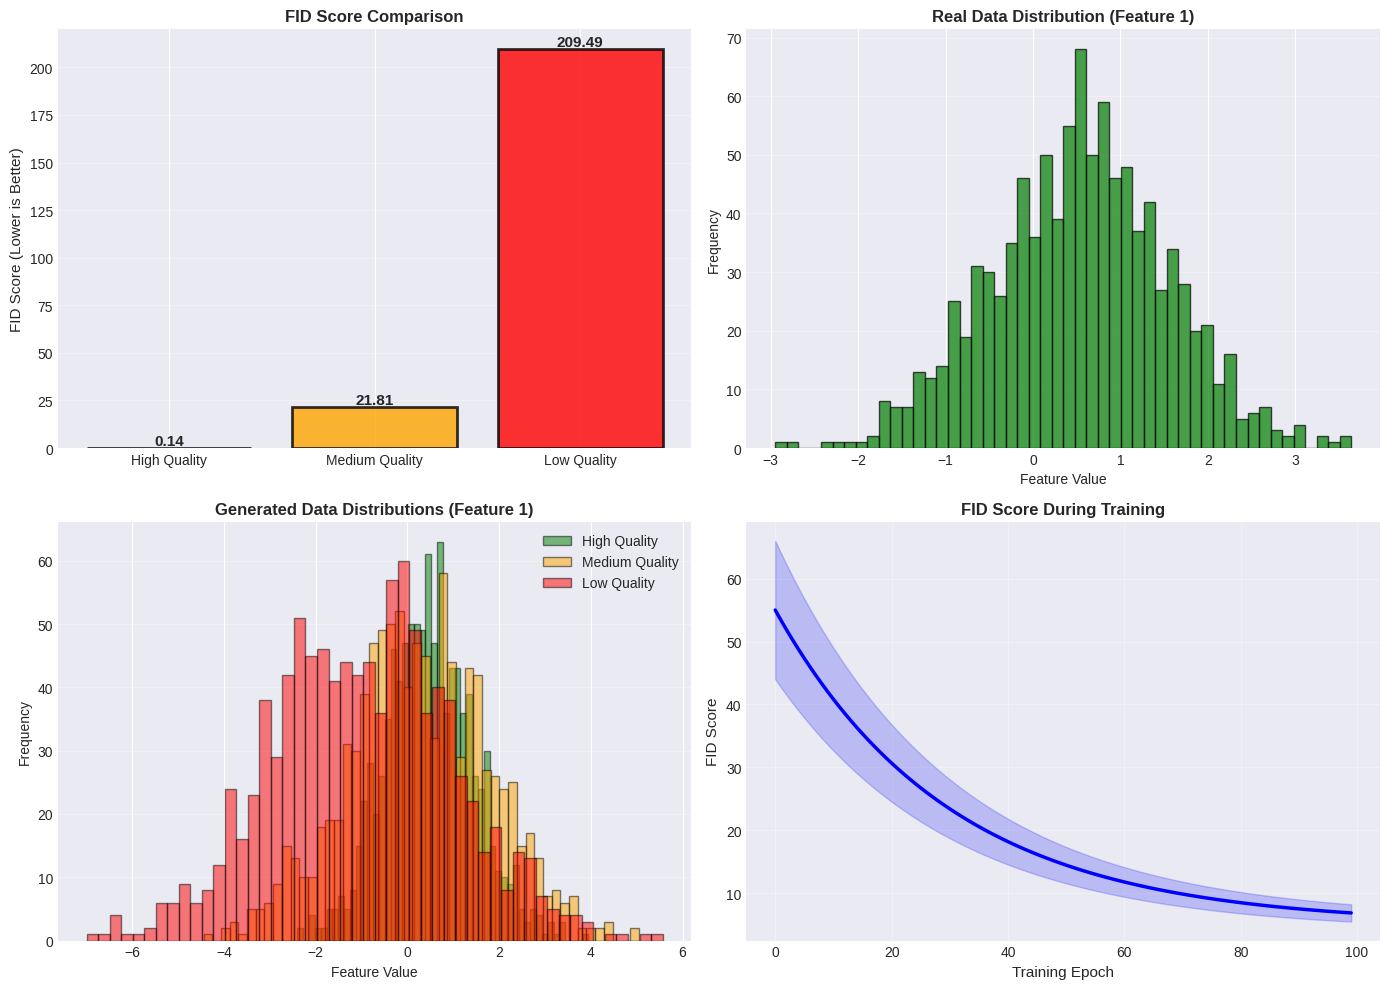


FID Score Results:
High Quality Generator:   FID = 0.1406
Medium Quality Generator: FID = 21.8095
Low Quality Generator:    FID = 209.4928


In [7]:
def compute_fid_score(real_features, fake_features):
    """
    Compute Fréchet Inception Distance.
    
    FID = ||μ_real - μ_fake||² + Tr(Σ_real + Σ_fake - 2√(Σ_real Σ_fake))
    
    Lower FID = better generated samples
    """
    # Compute means
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)
    
    # Compute covariances
    cov_real = np.cov(real_features.T)
    cov_fake = np.cov(fake_features.T)
    
    # Compute FID
    mean_diff = np.sum((mu_real - mu_fake) ** 2)
    
    # Ensure matrices are 2D for matrix square root
    if cov_real.ndim == 1:
        cov_real = cov_real.reshape(1, 1)
    if cov_fake.ndim == 1:
        cov_fake = cov_fake.reshape(1, 1)
    
    try:
        sqrt_product = np.sqrt(cov_real @ cov_fake)
        trace_term = np.trace(cov_real + cov_fake - 2 * sqrt_product)
    except:
        trace_term = 0
    
    fid = mean_diff + trace_term
    return fid

# Simulate different quality generators
np.random.seed(42)
n_samples = 1000
feature_dim = 64  # Feature dimension

# Real data: Gaussian with mean=0.5, std=1.0
real_features = np.random.normal(loc=0.5, scale=1.0, size=(n_samples, feature_dim))

# High-quality generator: close to real distribution
generated_high = np.random.normal(loc=0.48, scale=1.02, size=(n_samples, feature_dim))

# Medium-quality generator: shifted distribution
generated_medium = np.random.normal(loc=0.2, scale=1.5, size=(n_samples, feature_dim))

# Low-quality generator: very different distribution
generated_low = np.random.normal(loc=-1.0, scale=2.0, size=(n_samples, feature_dim))

# Compute FID scores
fid_high = compute_fid_score(real_features, generated_high)
fid_medium = compute_fid_score(real_features, generated_medium)
fid_low = compute_fid_score(real_features, generated_low)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# FID scores bar chart
ax = axes[0, 0]
models = ['High Quality', 'Medium Quality', 'Low Quality']
fids = [fid_high, fid_medium, fid_low]
colors = ['green', 'orange', 'red']
bars = ax.bar(models, fids, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('FID Score (Lower is Better)', fontsize=11)
ax.set_title('FID Score Comparison', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, fid_score in zip(bars, fids):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{fid_score:.2f}',
           ha='center', va='bottom', fontsize=11, fontweight='bold')

# Real distribution
ax = axes[0, 1]
ax.hist(real_features[:, 0], bins=50, alpha=0.7, color='green', edgecolor='black')
ax.set_title('Real Data Distribution (Feature 1)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Value')
ax.set_ylabel('Frequency')
ax.grid(axis='y', alpha=0.3)

# Generated distributions
ax = axes[1, 0]
ax.hist(generated_high[:, 0], bins=50, alpha=0.5, color='green', label='High Quality', edgecolor='black')
ax.hist(generated_medium[:, 0], bins=50, alpha=0.5, color='orange', label='Medium Quality', edgecolor='black')
ax.hist(generated_low[:, 0], bins=50, alpha=0.5, color='red', label='Low Quality', edgecolor='black')
ax.set_title('Generated Data Distributions (Feature 1)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Value')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Training progress (FID over epochs)
ax = axes[1, 1]
epochs = np.arange(0, 100)
fid_progress = 50 * np.exp(-epochs / 30) + 5  # Exponential decay
ax.plot(epochs, fid_progress, 'b-', linewidth=2.5)
ax.fill_between(epochs, fid_progress * 0.8, fid_progress * 1.2, alpha=0.2, color='blue')
ax.set_xlabel('Training Epoch', fontsize=11)
ax.set_ylabel('FID Score', fontsize=11)
ax.set_title('FID Score During Training', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fid_score.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nFID Score Results:")
print(f"High Quality Generator:   FID = {fid_high:.4f}")
print(f"Medium Quality Generator: FID = {fid_medium:.4f}")
print(f"Low Quality Generator:    FID = {fid_low:.4f}")

## 6. Generative Model Comparison

Key differences and trade-offs between GAN, VAE, and Diffusion models.

In [8]:
# Comprehensive model comparison
comparison_data = {
    'Aspect': [
        'Training Stability',
        'Mode Coverage',
        'Sample Quality',
        'Inference Speed',
        'Training Speed',
        'Likelihood Explicit',
        'Interpretability',
        'Controllability'
    ],
    'GAN': ['Unstable', 'Mode collapse', 'Very High', 'Very Fast', 'Fast', 'No', 'Low', 'Medium'],
    'VAE': ['Stable', 'Good', 'Good', 'Fast', 'Medium', 'Yes', 'High', 'High'],
    'Diffusion': ['Very Stable', 'Excellent', 'Very High', 'Slow', 'Slow', 'Yes', 'High', 'Very High']
}

comparison_df = pd.DataFrame(comparison_data)

print("\nGenerative Model Comparison\n")
print("=" * 100)
print(comparison_df.to_string(index=False))

print("\n\nDetailed Characteristics:\n")

details = {
    'GAN (Generative Adversarial Network)': [
        '• Generator vs Discriminator: Minimax game',
        '• Strengths: Fast inference, high-quality samples, sparse latent space',
        '• Weaknesses: Training instability, mode collapse, hard to quantify likelihood',
        '• Best for: High-quality image synthesis when training is successful',
        '• Applications: Image generation, style transfer, super-resolution'
    ],
    'VAE (Variational Autoencoder)': [
        '• Encoder-Decoder with KL regularization of latent space',
        '• Strengths: Stable training, interpretable latent space, explicit likelihood',
        '• Weaknesses: Blurry outputs (optimization bias toward MSE), mode-averaging',
        '• Best for: Learning interpretable representations and dense latent spaces',
        '• Applications: Anomaly detection, data interpolation, semisupervised learning'
    ],
    'Diffusion Models': [
        '• Iterative denoising: noise → data through many steps',
        '• Strengths: Excellent quality, very stable, explicitly probabilistic, flexible',
        '• Weaknesses: Slow inference (many steps needed), slow training, high compute',
        '• Best for: Maximum quality and controllability when compute is available',
        '• Applications: DALL-E, Stable Diffusion, audio synthesis, protein structure'
    ]
}

for model_type, characteristics in details.items():
    print(f"{model_type}:")
    for char in characteristics:
        print(f"  {char}")
    print()


Generative Model Comparison

             Aspect           GAN    VAE   Diffusion
 Training Stability      Unstable Stable Very Stable
      Mode Coverage Mode collapse   Good   Excellent
     Sample Quality     Very High   Good   Very High
    Inference Speed     Very Fast   Fast        Slow
     Training Speed          Fast Medium        Slow
Likelihood Explicit            No    Yes         Yes
   Interpretability           Low   High        High
    Controllability        Medium   High   Very High


Detailed Characteristics:

GAN (Generative Adversarial Network):
  • Generator vs Discriminator: Minimax game
  • Strengths: Fast inference, high-quality samples, sparse latent space
  • Weaknesses: Training instability, mode collapse, hard to quantify likelihood
  • Best for: High-quality image synthesis when training is successful
  • Applications: Image generation, style transfer, super-resolution

VAE (Variational Autoencoder):
  • Encoder-Decoder with KL regularization of latent sp

## Summary

Key takeaways:
1. **GANs**: Fast, high-quality samples, but training is unstable and can suffer from mode collapse
2. **VAEs**: Stable, interpretable latent space, but tend to produce blurry outputs
3. **Diffusion Models**: State-of-the-art quality, highly flexible, but slow and computationally expensive
4. **FID Score**: Key metric for evaluating generative model quality
5. **Choice depends on**: Quality needed vs. speed requirements vs. compute availability

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>